# 08 — Unsupervised learning

**Dataset:** `drive_day_2026`

**Question:** Which stable operating regimes appear without recurrence-derived labels?

## Method

Fit robust window features and K-means on training recordings. Select cluster count by internal structure and seed stability.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_fusion import render_unsupervised_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "drive_day_2026"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,07173121b1534f1eadb8b127005d4eff70872388074c2b...,21.9,moving_candidate,False,recorded_time_column,train
1,1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316...,21.9,moving_candidate,False,recorded_time_column,train
2,1cca7c275163fc193899535ebb0c13f26676e8568d3c8a...,37.9,moving_candidate,False,recorded_time_column,train
3,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,57.8,moving_candidate,False,recorded_time_column,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,73.7,moving_candidate,False,recorded_time_column,train
5,2f775054c4e7bb342cf49e0ee66406e82353c274c103fc...,25.9,moving_candidate,False,recorded_time_column,train
6,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,57.8,stationary_candidate,True,recorded_time_column,train
7,4c8d0190b666e26315ce16c862ca2e968d576e14537487...,21.9,moving_candidate,False,recorded_time_column,train
8,554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa...,17.9,stationary_candidate,True,recorded_time_column,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,57.8,stationary_candidate,True,recorded_time_column,train


In [2]:
EXPERIMENT_OPTIONS = {}
EXPERIMENT_OPTIONS

{}

,task,split,metric,value,sample_count,reference_source
0,driving_regime_clustering,train,selected_cluster_count,3.000000,333,internal_selection
1,driving_regime_clustering,train,silhouette,0.862058,333,internal_only
2,driving_regime_clustering,train,seed_adjusted_rand_index,1.000000,333,internal_only
3,driving_regime_clustering,train,mean_centroid_distance,5.320191,333,none
4,driving_regime_clustering,validation,mean_centroid_distance,4.854485,108,none
5,driving_regime_clustering,test,mean_centroid_distance,4.312816,59,none
6,driving_regime_clustering,all,mean_centroid_distance,5.100729,500,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,500,21,667a6e15a4394db30d7cce7a4db319041453bfa306b566...,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,500,500,window_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,500.0,NaN,NaN,NaN,43.528,49.015163,0.0,11.5,27.0,54.0,218.0
end_s,500.0,NaN,NaN,NaN,53.528,49.015163,10.0,21.5,37.0,64.0,228.0
prediction_kind,500,1,driving_regime_cluster,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,500.0,NaN,NaN,NaN,-5.100729,4.290295,-29.671185,-5.184385,-3.670431,-3.02477,-1.493241
label_status,500,1,provisional_unverified,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,500.0,NaN,NaN,NaN,0.066,0.292943,0.0,0.0,0.0,0.0,2.0
distance_to_centroid,500.0,NaN,NaN,NaN,5.100729,4.290295,1.493241,3.02477,3.670431,5.184385,29.671185


,count,mean,median,std,min,max
recording_id,,,,,,
629d7d57091b71c5c0c2c6f42218702e454b4ae60e20636885741c7c22fe1bb4,38,-2.800662,-2.681114,0.615598,-3.989223,-1.493241
200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c71731d7739c8ecbda5e,24,-3.007554,-2.721270,0.807498,-4.575970,-1.686391
6faa006353747cbeb4e6d2e90954728110cb94fabfcd41e319270d4cde22f117,40,-5.212173,-2.916112,4.642476,-16.809818,-2.086811
07173121b1534f1eadb8b127005d4eff70872388074c2bbe0c93061527d89f40,7,-3.882193,-2.994269,1.364602,-6.175443,-2.809645
1cca7c275163fc193899535ebb0c13f26676e8568d3c8adac48dbcc224812b0c,15,-3.306222,-3.071673,0.927229,-6.219720,-2.598277
f26c5b91a912f9e98e0205e2518d5b3de0314b04b69c3bc6d0148fa8ea3e842b,7,-3.412300,-3.374689,0.793691,-4.944972,-2.614484
5e9e04831922d971561f6ffb53b2c77744d905cca01dcc2fe043d10b2f63c613,16,-3.714720,-3.383077,1.717832,-6.117641,-1.683700
953f71ef131b4c5ce7211560abcbafbfe0079e72cf2190c2908d3ff00cf5db12,40,-3.641305,-3.637541,0.013057,-3.674307,-3.618496
382db1f8ede73f956341d7b461790125339762ec9d7cc96480f20aefe04d77e1,24,-3.642768,-3.639982,0.009318,-3.659629,-3.631335


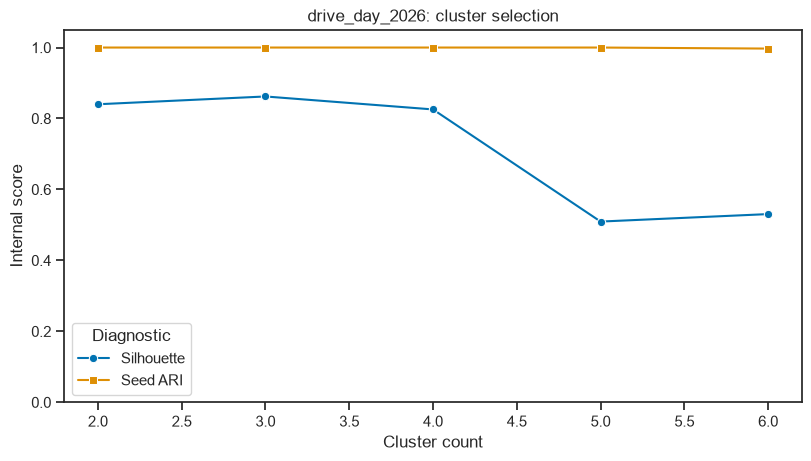

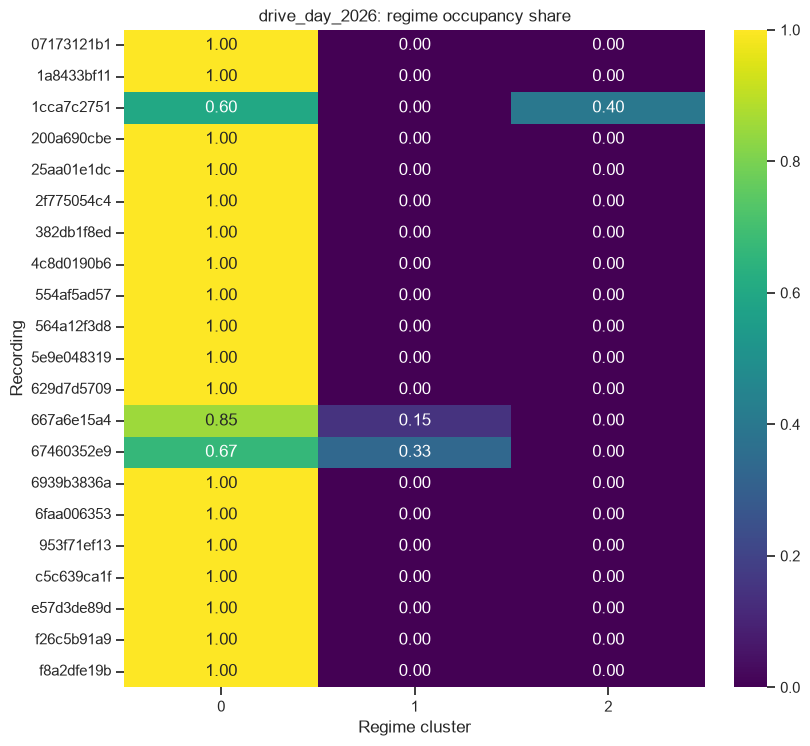

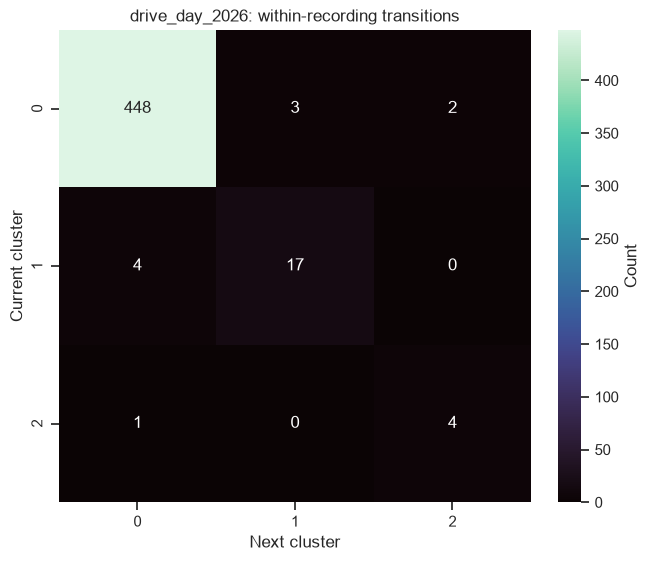

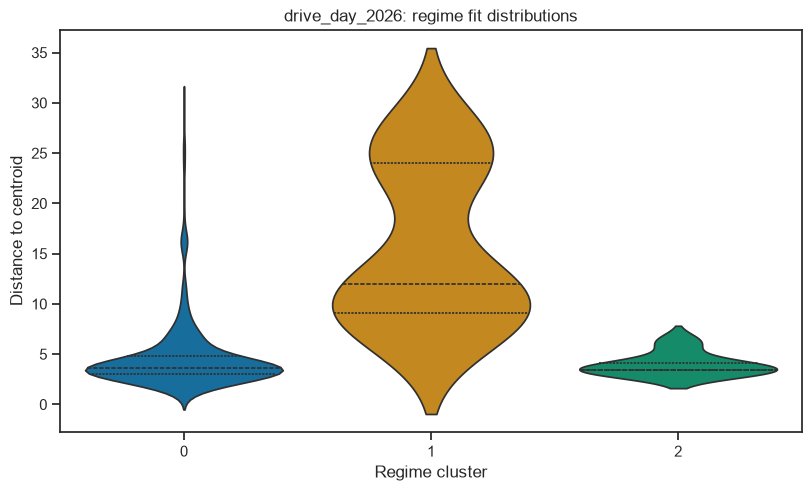

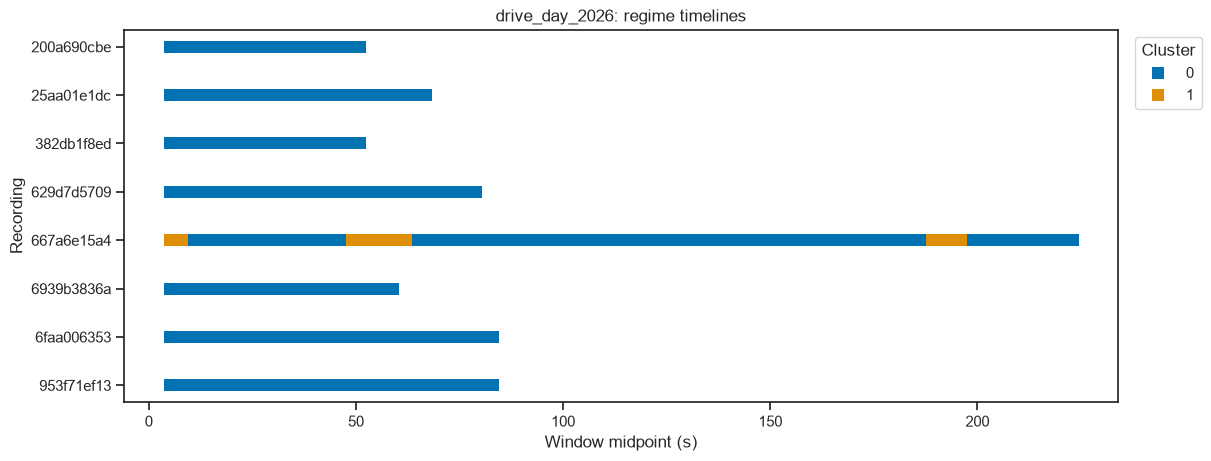

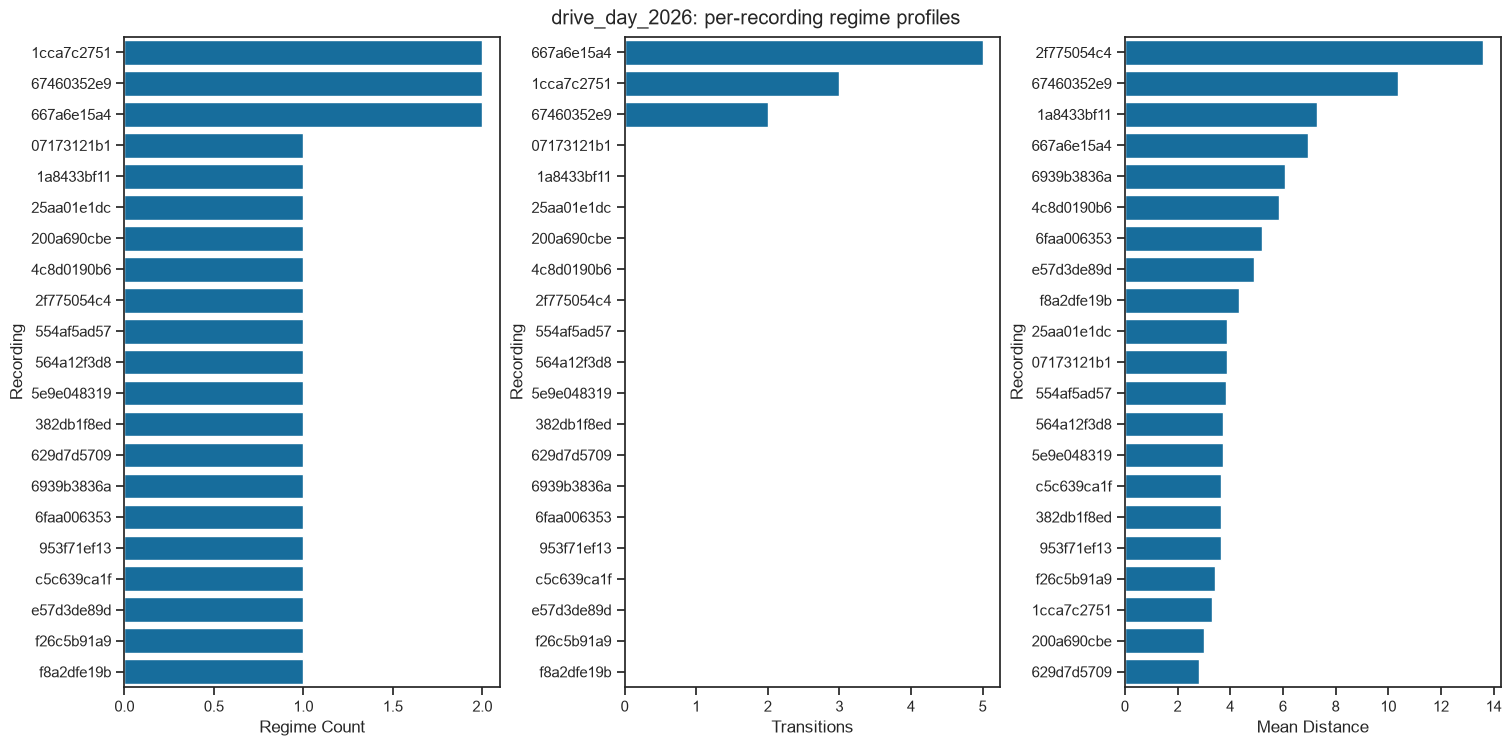

In [3]:
METHOD = "08_unsupervised_learning"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_unsupervised_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,1.374
clock_provenance,recorded_time_column
sample_rate_hz,10.0
channels,"[Motor RPM [Rpm], MC Duty Cycle [%], AC Curren..."
label_provenance,cluster_regime_not_lap


## Reading

Stable clusters describe regimes until independent lap labels exist.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.